# 😴 Human Stress Detection Based on Sleeping Habits
### AI Course Project | SaYoPillow Dataset (IEEE Research)
**Student:** Marium Ahmad

---
## Project Steps:
1. 🧹 Data Cleaning
2. 📊 Exploratory Data Analysis (EDA)
3. ⚙️ Feature Engineering & Preprocessing
4. 🤖 Model Building
5. 📈 Evaluation
6. 🚀 Improvement
7. 🌐 Website (Streamlit)
8. ☁️ Deployment

---
### 📌 About the Dataset (SaYoPillow):
> This is a **real research dataset** published in the **IEEE Transactions journal**.
> It monitors physiological signals during sleep to detect stress levels.
>
> | Column | Meaning |
> |--------|---------|
> | sr  | Snoring Rate (%) |
> | rr  | Respiration Rate |
> | t   | Body Temperature (°F) |
> | lm  | Limb Movement Rate |
> | bo  | Blood Oxygen Level (%) |
> | rem | REM Sleep (%) |
> | sr.1| Sleep Hours |
> | hr  | Heart Rate (BPM) |
> | sl  | **Stress Level** (0=Low → 4=High) ← Target |


## 📦 Import All Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report,
                              precision_score, recall_score, f1_score)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## Step 1: 🧹 Data Cleaning

**What is Data Cleaning?**
> We load the dataset and:
> - Rename columns to meaningful names
> - Check for missing values
> - Check for duplicate rows
> - Understand the target column (stress levels)


In [2]:
# Load dataset
df = pd.read_csv('SaYoPillow.csv') 
print("📂 Dataset loaded!")
print(f"Shape: {df.shape}")
df.head(10)


📂 Dataset loaded!
Shape: (630, 9)


,sr,rr,t,lm,bo,rem,sr.1,hr,sl
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0
5,56.88,19.376,95.376,9.376,94.064,83.44,6.376,58.44,1
6,47.00,16.800,97.200,5.600,95.800,68.00,7.800,52.00,0
7,50.00,18.000,99.000,8.000,97.000,80.00,9.000,55.00,0
8,45.28,16.112,96.168,4.224,95.112,61.12,7.112,50.28,0
9,55.52,19.104,95.104,9.104,93.656,82.76,6.104,57.76,1


In [3]:
# Rename columns to meaningful names
df.rename(columns={
    'sr'  : 'snoring_rate',
    'rr'  : 'respiration_rate',
    't'   : 'body_temperature',
    'lm'  : 'limb_movement',
    'bo'  : 'blood_oxygen',
    'rem' : 'rem_sleep',
    'sr.1': 'sleep_hours',
    'hr'  : 'heart_rate',
    'sl'  : 'stress_level'
}, inplace=True)

print("✅ Columns renamed!")
df.head()


✅ Columns renamed!


,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,rem_sleep,sleep_hours,heart_rate,stress_level
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [4]:
# Check data types
print("Data Types:")
print(df.dtypes)


Data Types:
snoring_rate        float64
respiration_rate    float64
body_temperature    float64
limb_movement       float64
blood_oxygen        float64
rem_sleep           float64
sleep_hours         float64
heart_rate          float64
stress_level          int64
dtype: object


In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print()

# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"✅ Shape after cleaning: {df.shape}")


Missing Values:
snoring_rate        0
respiration_rate    0
body_temperature    0
limb_movement       0
blood_oxygen        0
rem_sleep           0
sleep_hours         0
heart_rate          0
stress_level        0
dtype: int64

Duplicate rows: 0
✅ Shape after cleaning: (630, 9)


In [6]:
# Target column distribution
print("Stress Level Distribution:")
print(df['stress_level'].value_counts().sort_index())
print()
print("Stress Level Meaning:")
stress_labels = {0:'Low', 1:'Low-Medium', 2:'Medium', 3:'Medium-High', 4:'High'}
for k,v in stress_labels.items():
    print(f"  {k} = {v}")


Stress Level Distribution:
stress_level
0    126
1    126
2    126
3    126
4    126
Name: count, dtype: int64

Stress Level Meaning:
  0 = Low
  1 = Low-Medium
  2 = Medium
  3 = Medium-High
  4 = High


In [7]:
# Basic statistics
print("📊 Dataset Statistics:")
df.describe().round(2)


📊 Dataset Statistics:


,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,rem_sleep,sleep_hours,heart_rate,stress_level
count,630.00,630.00,630.00,630.00,630.00,630.00,630.00,630.00,630.00
mean,71.60,21.80,92.80,11.70,90.90,88.50,3.70,64.50,2.00
std,19.37,3.97,3.53,4.30,3.90,11.89,3.05,9.92,1.42
min,45.00,16.00,85.00,4.00,82.00,60.00,0.00,50.00,0.00
25%,52.50,18.50,90.50,8.50,88.50,81.25,0.50,56.25,1.00
50%,70.00,21.00,93.00,11.00,91.00,90.00,3.50,62.50,2.00
75%,91.25,25.00,95.50,15.75,94.25,98.75,6.50,72.50,3.00
max,100.00,30.00,99.00,19.00,97.00,105.00,9.00,85.00,4.00


---
## Step 2: 📊 Exploratory Data Analysis (EDA)

**What is EDA?**
> We explore the data visually to understand:
> - Distribution of stress levels
> - How each feature changes across stress levels
> - Which features are most correlated with stress


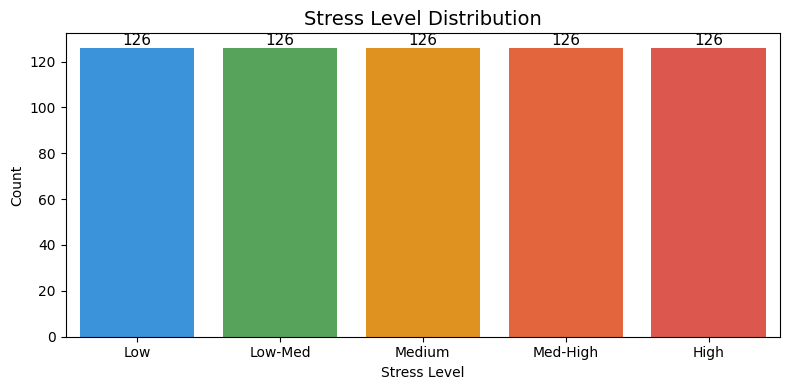

In [8]:
# 2.1 Stress level distribution - Count plot
stress_labels = {0:'Low', 1:'Low-Med', 2:'Medium', 3:'Med-High', 4:'High'}
colors = ['#2196F3','#4CAF50','#FF9800','#FF5722','#F44336']

plt.figure(figsize=(8,4))
ax = sns.countplot(x='stress_level', data=df, palette=colors)
ax.set_xticklabels([stress_labels[i] for i in range(5)])
plt.title('Stress Level Distribution', fontsize=14)
plt.xlabel('Stress Level')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2, p.get_height()+1),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()


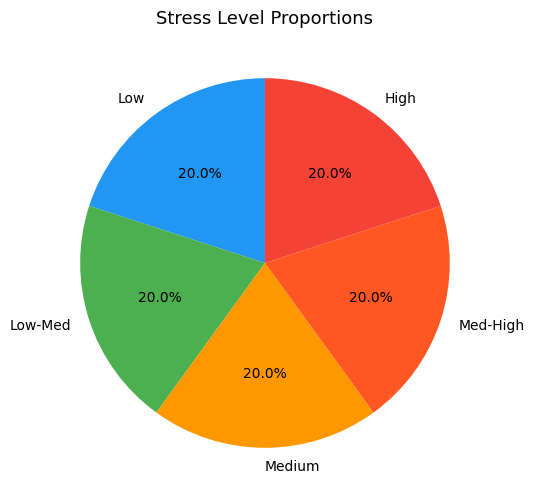

In [9]:
# 2.2 Pie chart
plt.figure(figsize=(6,6))
df['stress_level'].value_counts().sort_index().plot(
    kind='pie',
    labels=[stress_labels[i] for i in range(5)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title('Stress Level Proportions', fontsize=13)
plt.ylabel('')
plt.show()


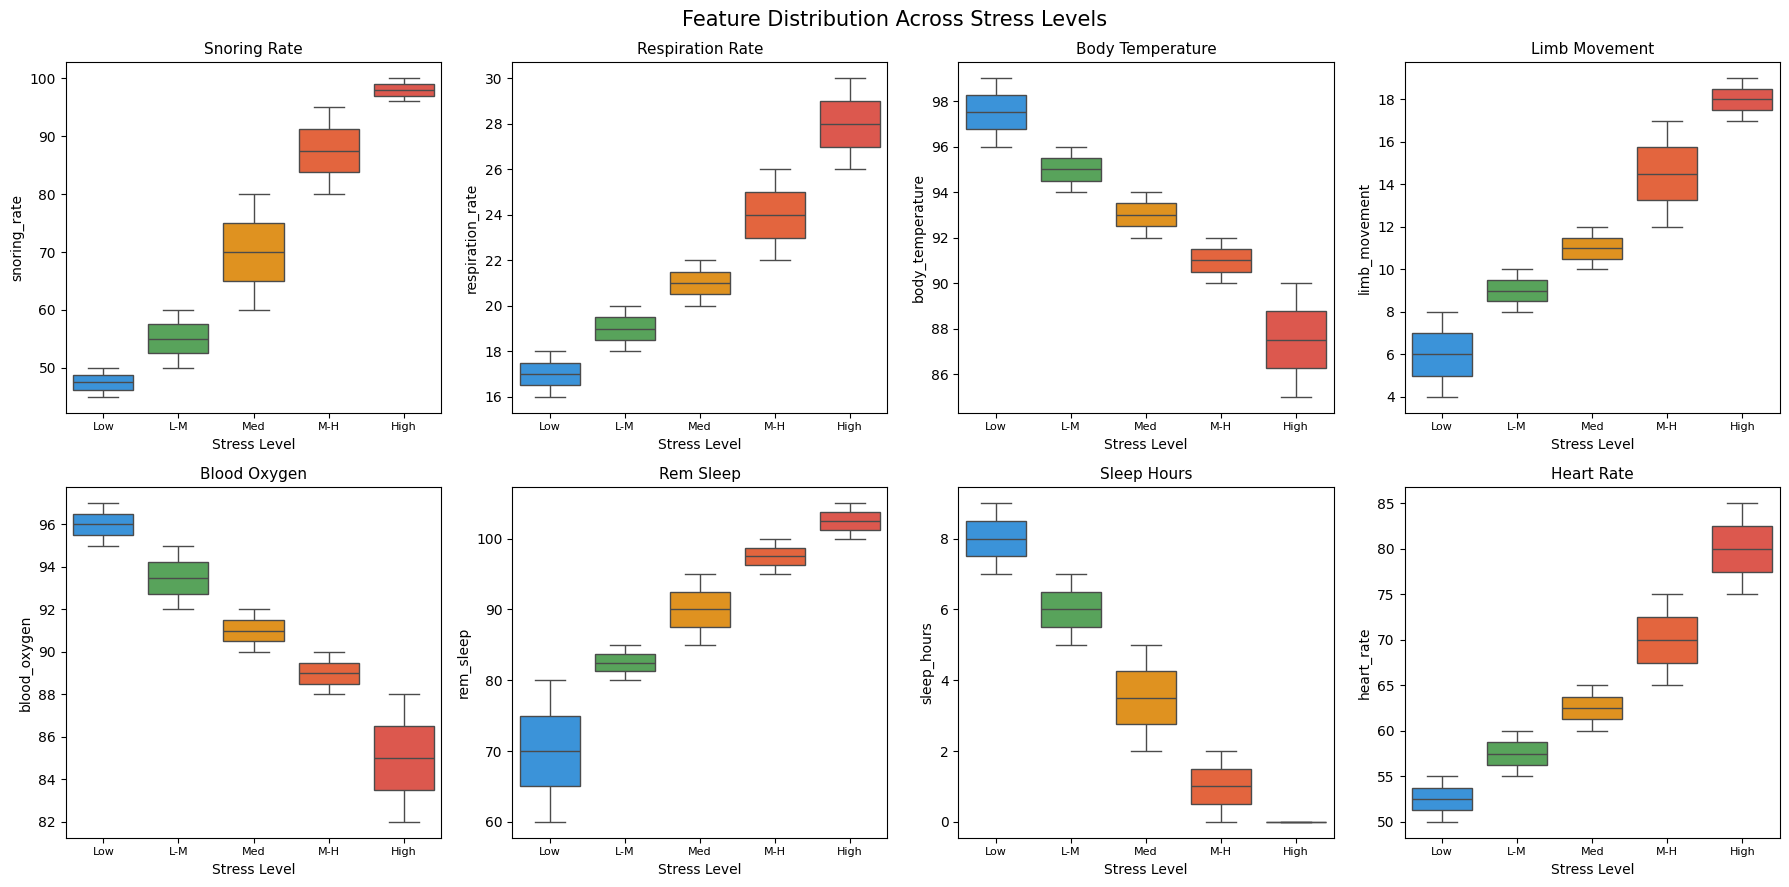

In [10]:
# 2.3 Box plots — all features vs stress level
features = ['snoring_rate','respiration_rate','body_temperature',
            'limb_movement','blood_oxygen','rem_sleep',
            'sleep_hours','heart_rate']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x='stress_level', y=feat, data=df,
                palette=colors, ax=axes[i])
    axes[i].set_title(feat.replace('_',' ').title(), fontsize=11)
    axes[i].set_xticklabels(['Low','L-M','Med','M-H','High'], fontsize=8)
    axes[i].set_xlabel('Stress Level')

plt.suptitle('Feature Distribution Across Stress Levels', fontsize=15)
plt.tight_layout()
plt.show()


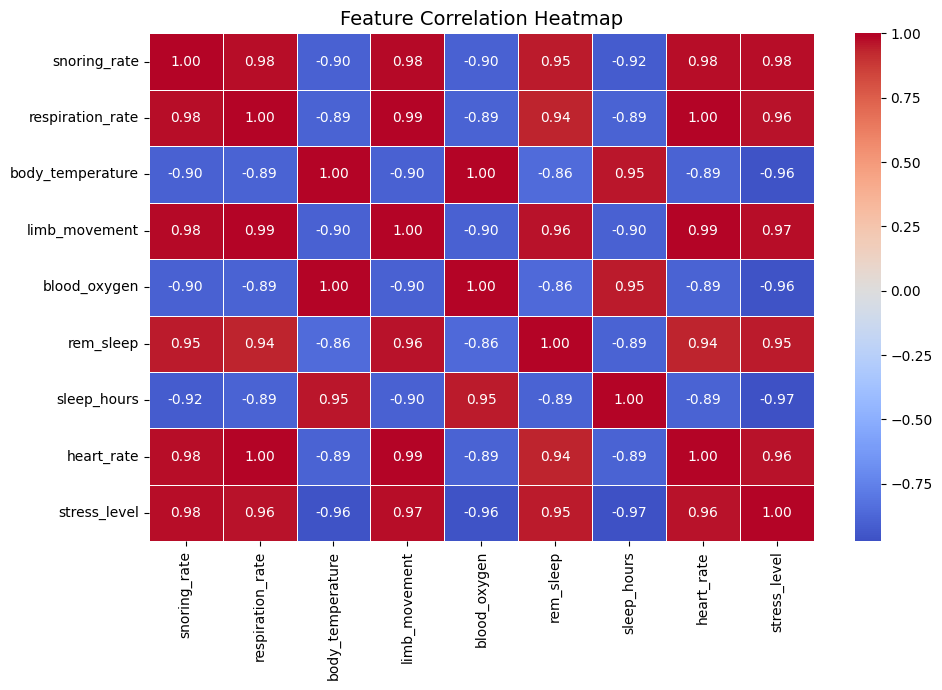

In [11]:
# 2.4 Heatmap — correlation between all features
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


In [12]:
# 2.5 Mean values per stress level
avg = df.groupby('stress_level').mean().round(2)
avg.index = [stress_labels[i] for i in range(5)]
print("📊 Average feature values per stress level:")
avg


📊 Average feature values per stress level:


,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,rem_sleep,sleep_hours,heart_rate
Low,47.5,17.0,97.5,6.0,96.0,70.0,8.0,52.5
Low-Med,55.0,19.0,95.0,9.0,93.5,82.5,6.0,57.5
Medium,70.0,21.0,93.0,11.0,91.0,90.0,3.5,62.5
Med-High,87.5,24.0,91.0,14.5,89.0,97.5,1.0,70.0
High,98.0,28.0,87.5,18.0,85.0,102.5,0.0,80.0


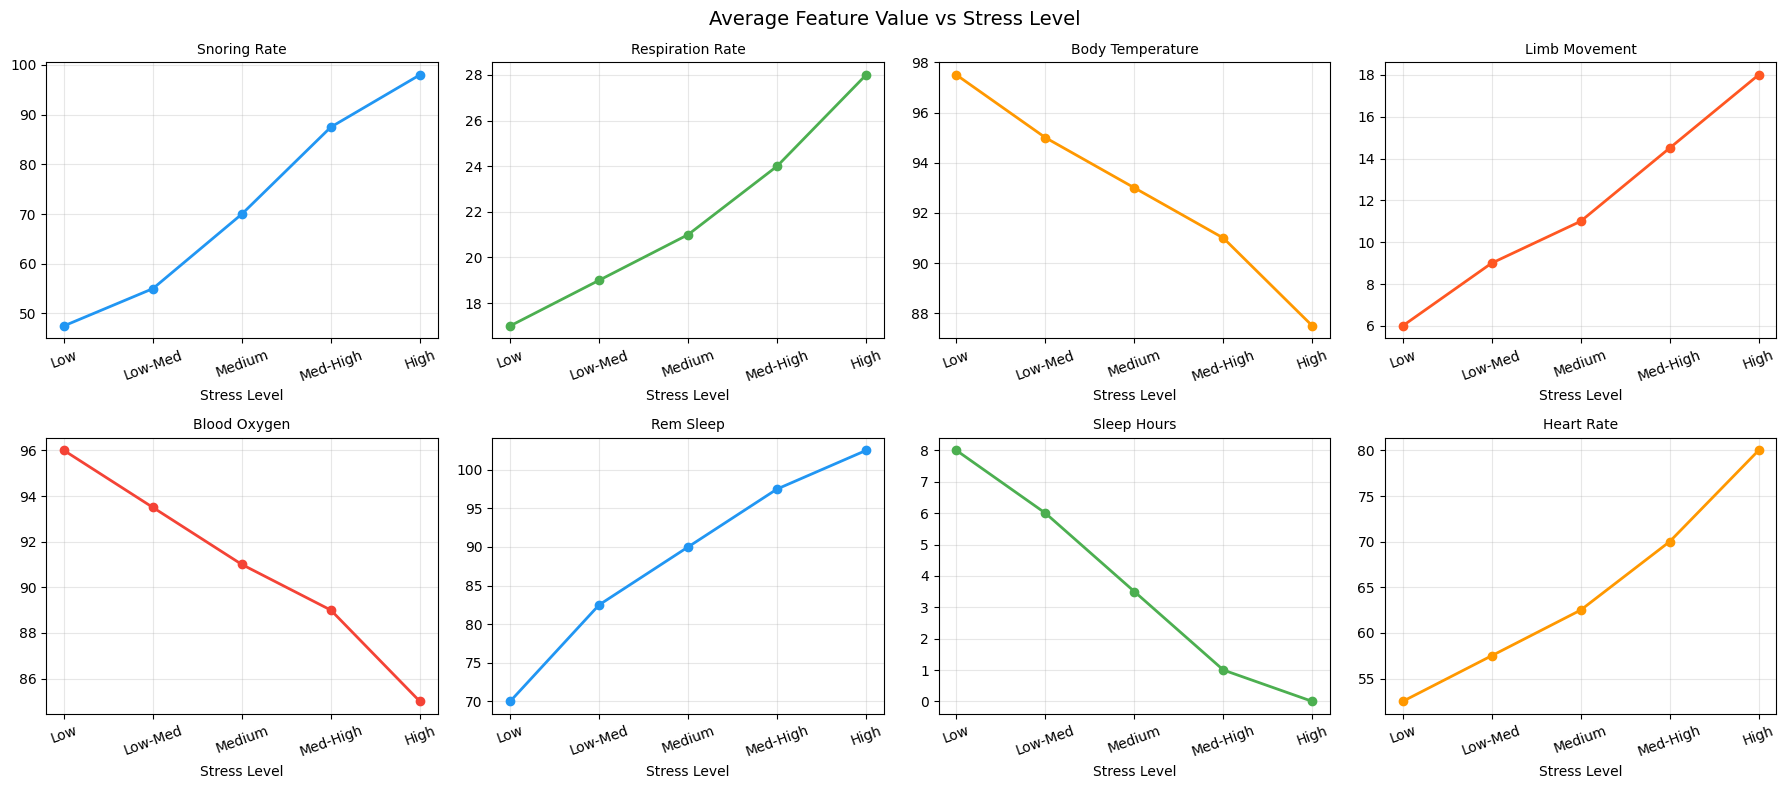

In [13]:
# 2.6 Line plot — how features change across stress levels
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    mean_vals = df.groupby('stress_level')[feat].mean()
    axes[i].plot(list(stress_labels.values()), mean_vals.values,
                 marker='o', color=colors[i % len(colors)], linewidth=2)
    axes[i].set_title(feat.replace('_',' ').title(), fontsize=10)
    axes[i].set_xlabel('Stress Level')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Average Feature Value vs Stress Level', fontsize=14)
plt.tight_layout()
plt.show()


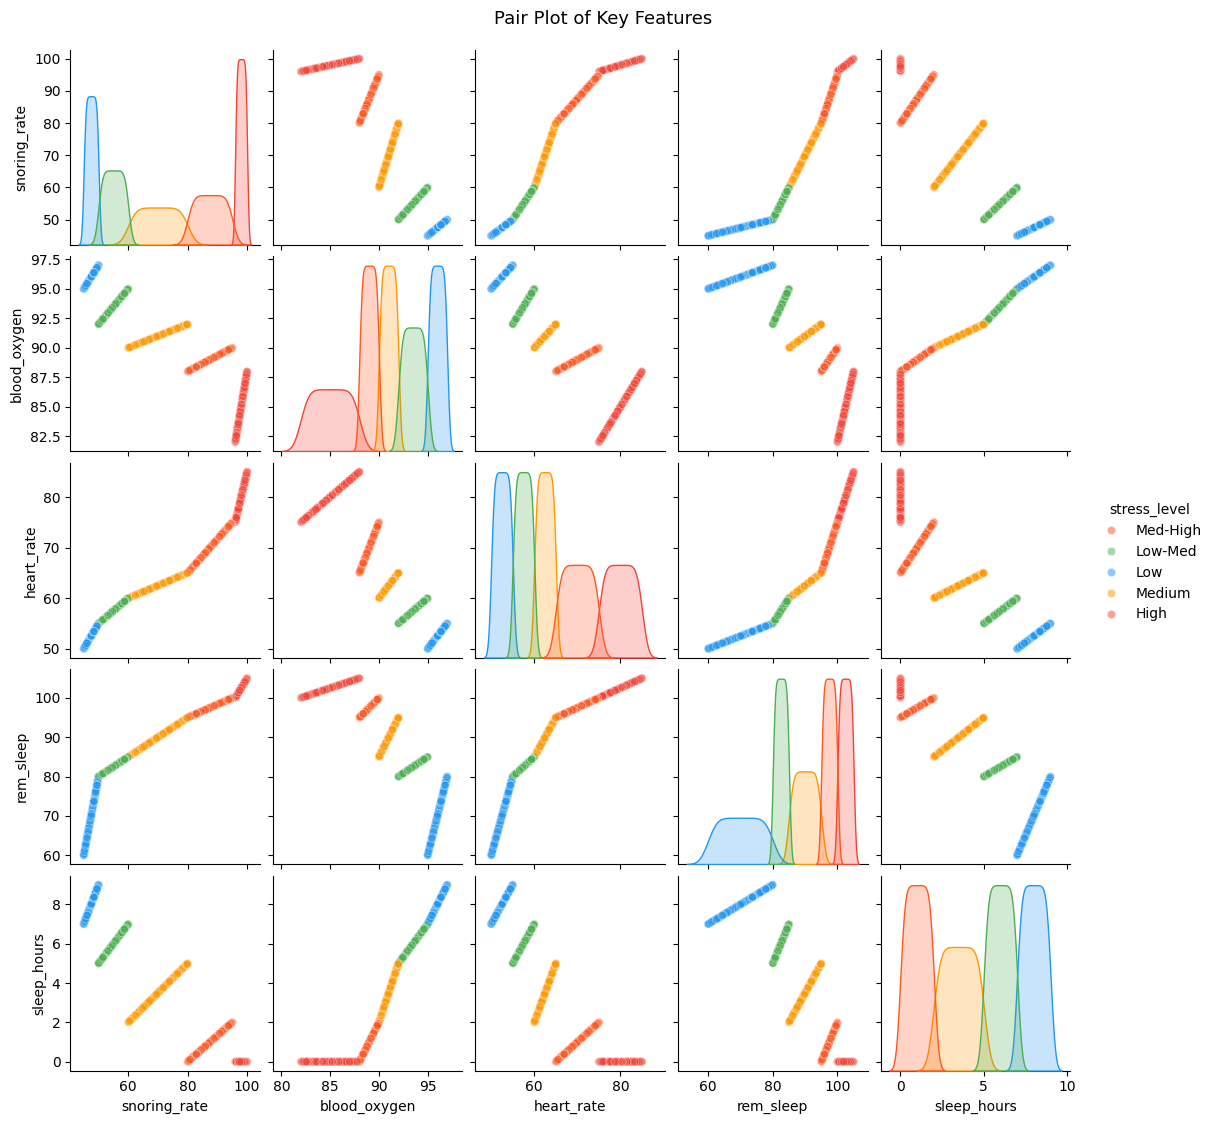

In [14]:
# 2.7 Pair plot for key features
key_features = ['snoring_rate','blood_oxygen','heart_rate',
                'rem_sleep','sleep_hours','stress_level']
pair_df = df[key_features].copy()
pair_df['stress_level'] = pair_df['stress_level'].map(stress_labels)

sns.pairplot(pair_df, hue='stress_level',
             palette={'Low':'#2196F3','Low-Med':'#4CAF50',
                      'Medium':'#FF9800','Med-High':'#FF5722','High':'#F44336'},
             plot_kws={'alpha':0.5}, height=2.2)
plt.suptitle('Pair Plot of Key Features', y=1.02, fontsize=13)
plt.show()


---
## Step 3: ⚙️ Feature Engineering & Preprocessing

**What is Feature Engineering?**
> We create new features from existing ones to help the model learn better.

**New features:**
- `oxygen_heart_ratio` = blood_oxygen ÷ heart_rate (higher = healthier)
- `sleep_quality_score` = rem_sleep × sleep_hours (combined sleep quality)
- `stress_indicator` = snoring_rate + limb_movement + respiration_rate (combined activity)


In [15]:
# Create new engineered features
df['oxygen_heart_ratio']  = (df['blood_oxygen'] / df['heart_rate']).round(3)
df['sleep_quality_score'] = (df['rem_sleep'] * df['sleep_hours']).round(3)
df['stress_indicator']    = (df['snoring_rate'] +
                              df['limb_movement'] +
                              df['respiration_rate']).round(3)

print("✅ New features created!")
df[['oxygen_heart_ratio','sleep_quality_score',
    'stress_indicator','stress_level']].head(8)


✅ New features created!


,oxygen_heart_ratio,sleep_quality_score,stress_indicator,stress_level
0,1.211,183.264,136.080,3
1,1.231,153.462,132.624,3
2,1.583,595.000,90.000,1
3,1.289,74.435,123.216,3
4,1.812,597.815,71.864,0
5,1.610,532.013,85.632,1
6,1.842,530.400,69.400,0
7,1.764,720.000,76.000,0


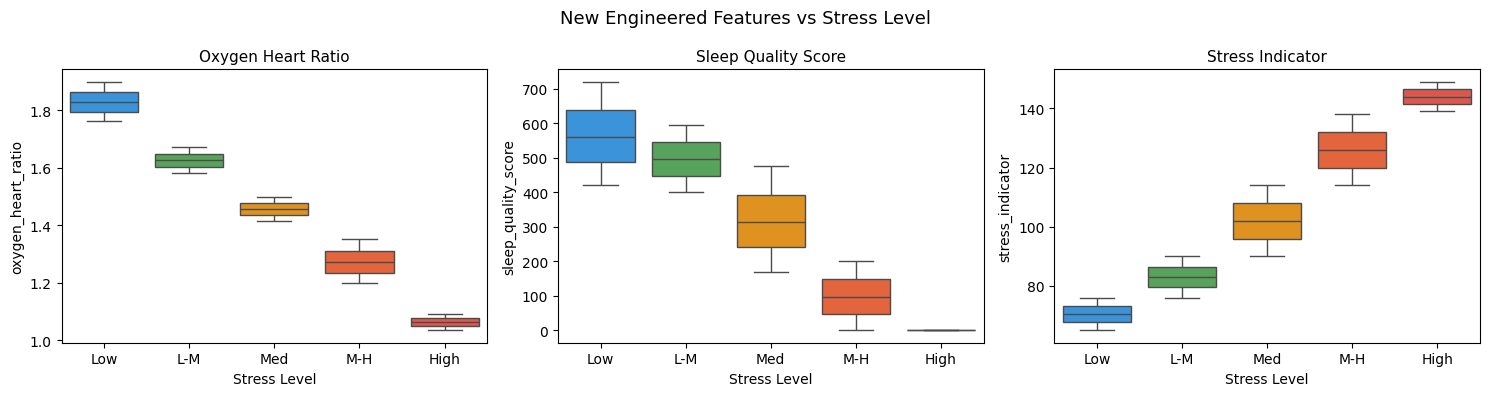

In [16]:
# Visualise new features vs stress level
new_feats = ['oxygen_heart_ratio','sleep_quality_score','stress_indicator']
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, feat in enumerate(new_feats):
    sns.boxplot(x='stress_level', y=feat, data=df,
                palette=colors, ax=axes[i])
    axes[i].set_title(feat.replace('_',' ').title(), fontsize=11)
    axes[i].set_xticklabels(['Low','L-M','Med','M-H','High'])
    axes[i].set_xlabel('Stress Level')

plt.suptitle('New Engineered Features vs Stress Level', fontsize=13)
plt.tight_layout()
plt.show()


In [17]:
# Prepare X and y
X = df.drop(columns=['stress_level'])
y = df['stress_level'].values

print(f"Features : {list(X.columns)}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")
print(f"Classes  : {np.unique(y)} → {[stress_labels[i] for i in np.unique(y)]}")


Features : ['snoring_rate', 'respiration_rate', 'body_temperature', 'limb_movement', 'blood_oxygen', 'rem_sleep', 'sleep_hours', 'heart_rate', 'oxygen_heart_ratio', 'sleep_quality_score', 'stress_indicator']
X shape  : (630, 11)
y shape  : (630,)
Classes  : [0 1 2 3 4] → ['Low', 'Low-Med', 'Medium', 'Med-High', 'High']


In [18]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print("✅ Data scaled and ready!")


Training samples : 504
Testing  samples : 126
✅ Data scaled and ready!


---
## Step 4: 🤖 Model Building

**What is Model Building?**
> We train 7 different Machine Learning models and compare them.
> This is a **multi-class classification** problem (5 stress levels: 0 to 4).


In [19]:
models = {
    'Logistic Regression'    : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine' : SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'            : GaussianNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall'   : recall_score(y_test, y_pred, average='weighted'),
        'F1 Score' : f1_score(y_test, y_pred, average='weighted'),
    }
    print(f"✅ {name} trained")

print("\n🎉 All models trained!")


✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained
✅ Gradient Boosting trained
✅ Support Vector Machine trained
✅ K-Nearest Neighbors trained
✅ Naive Bayes trained

🎉 All models trained!


---
## Step 5: 📈 Evaluation

**Note:** Since we have 5 stress levels (multi-class), we use
**weighted average** for Precision, Recall and F1-Score.


In [20]:
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df = results_df.map(lambda x: round(x*100, 2))
print("📊 Model Comparison (scores in %):")
results_df


📊 Model Comparison (scores in %):


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,100.00,100.00,100.00,100.00
Support Vector Machine,100.00,100.00,100.00,100.00
K-Nearest Neighbors,100.00,100.00,100.00,100.00
Naive Bayes,100.00,100.00,100.00,100.00
Decision Tree,98.41,98.53,98.41,98.43
Gradient Boosting,98.41,98.44,98.41,98.41
Random Forest,97.62,97.65,97.62,97.62


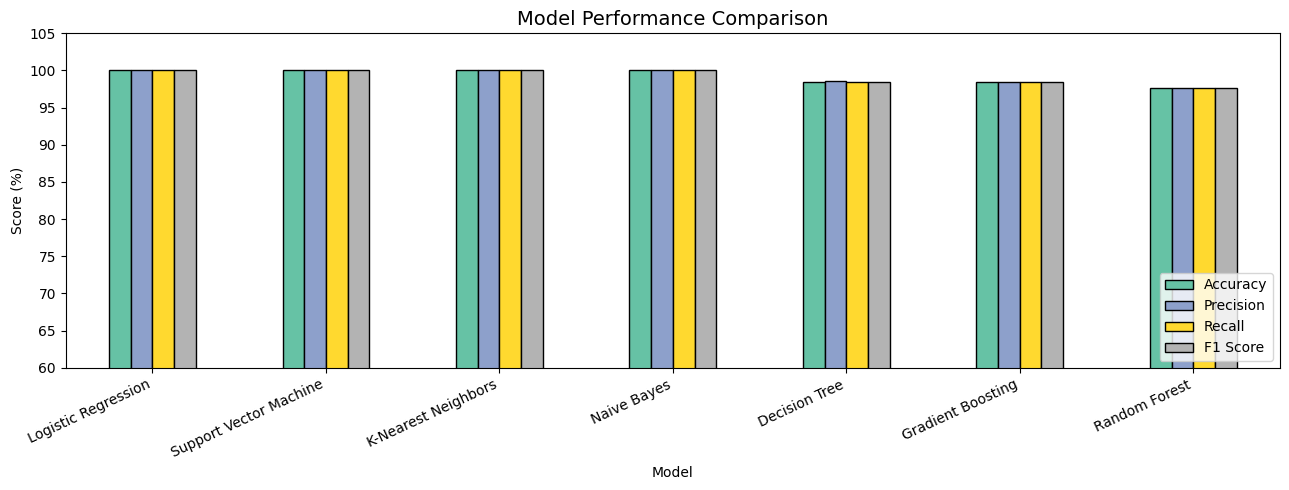

In [21]:
results_df.plot(kind='bar', figsize=(13,5),
                colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score (%)')
plt.xlabel('Model')
plt.xticks(rotation=25, ha='right')
plt.ylim([60, 105])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [22]:
# Detailed report for best model
best_name   = results_df['Accuracy'].idxmax()
best_model  = models[best_name]
y_pred_best = best_model.predict(X_test_s)

print(f"🏆 Best Model: {best_name}")
print("=" * 60)
print(classification_report(y_test, y_pred_best,
      target_names=['Low','Low-Med','Medium','Med-High','High']))


🏆 Best Model: Logistic Regression
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        25
     Low-Med       1.00      1.00      1.00        25
      Medium       1.00      1.00      1.00        25
    Med-High       1.00      1.00      1.00        26
        High       1.00      1.00      1.00        25

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



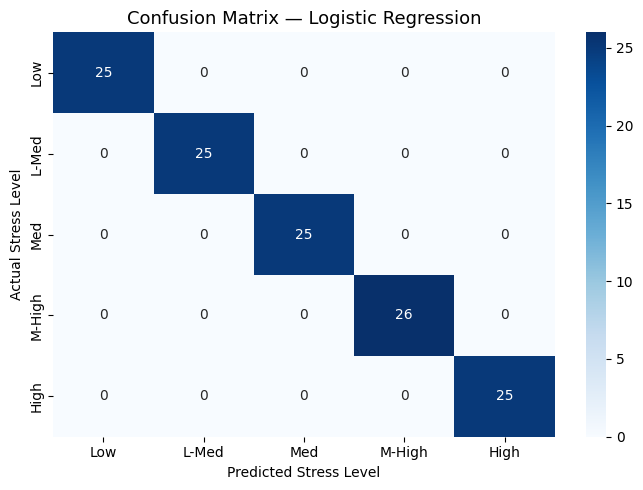

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','L-Med','Med','M-High','High'],
            yticklabels=['Low','L-Med','Med','M-High','High'])
plt.title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.ylabel('Actual Stress Level')
plt.xlabel('Predicted Stress Level')
plt.tight_layout()
plt.show()


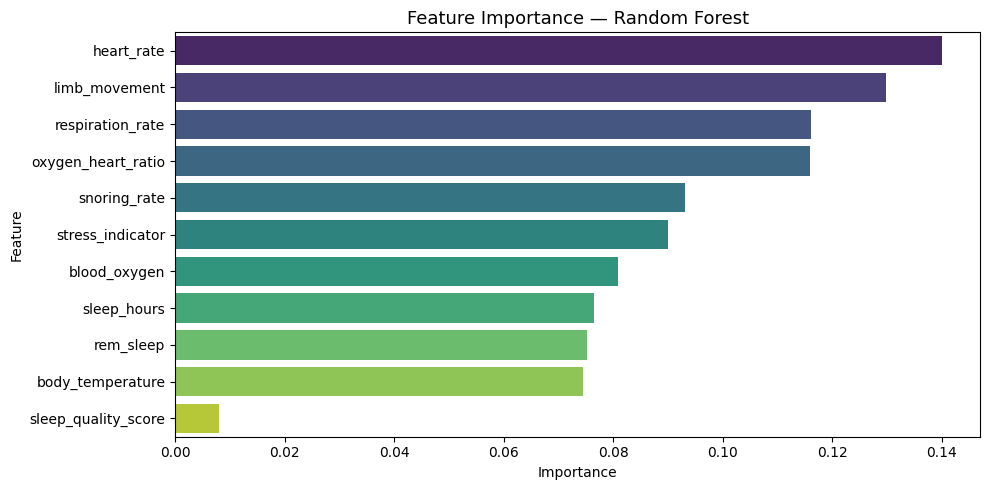

Top 3 most important features:
  heart_rate: 14.00%
  limb_movement: 12.99%
  respiration_rate: 11.61%


In [24]:
# Feature Importance (Random Forest)
rf = models['Random Forest']
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature',
            data=feat_imp, palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for i, row in feat_imp.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']*100:.2f}%")


---
## Step 6: 🚀 Improvement

**Improvement techniques:**
> 1. **Voting Classifier** — combine 3 best models
> 2. **5-Fold Cross Validation** — reliable accuracy estimate
> 3. **Save** the final model for the website


In [25]:
# Voting Classifier
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr',lr), ('rf',rf), ('gb',gb)],
    voting='hard'
)
voting_clf.fit(X_train_s, y_train)
y_pred_v = voting_clf.predict(X_test_s)

acc  = accuracy_score(y_test, y_pred_v)
prec = precision_score(y_test, y_pred_v, average='weighted')
rec  = recall_score(y_test, y_pred_v, average='weighted')
f1   = f1_score(y_test, y_pred_v, average='weighted')

print("🏆 Voting Classifier Results:")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")


🏆 Voting Classifier Results:
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%


In [26]:
# 5-Fold Cross Validation
all_X_s = scaler.transform(X)
cv_scores = cross_val_score(voting_clf, all_X_s, y, cv=5, scoring='accuracy')

print("5-Fold Cross Validation Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s*100:.2f}%")
print(f"\nMean Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation  : {cv_scores.std()*100:.2f}%")


5-Fold Cross Validation Scores:
  Fold 1: 99.21%
  Fold 2: 99.21%
  Fold 3: 100.00%
  Fold 4: 100.00%
  Fold 5: 100.00%

Mean Accuracy : 99.68%
Std Deviation  : 0.39%


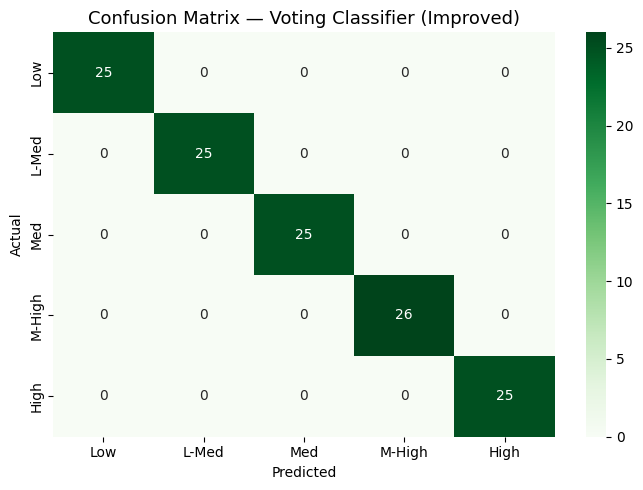

In [27]:
# Confusion matrix — improved model
cm_v = confusion_matrix(y_test, y_pred_v)
plt.figure(figsize=(7,5))
sns.heatmap(cm_v, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low','L-Med','Med','M-High','High'],
            yticklabels=['Low','L-Med','Med','M-High','High'])
plt.title('Confusion Matrix — Voting Classifier (Improved)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [28]:
# Final comparison table
print("=" * 58)
print(f"{'Model':<38} {'Accuracy':>10} {'F1 Score':>10}")
print("=" * 58)
print(f"{'Original Best: '+best_name:<38} "
      f"{results_df.loc[best_name,'Accuracy']:>9.2f}% "
      f"{results_df.loc[best_name,'F1 Score']:>9.2f}%")
print(f"{'Improved: Voting Classifier':<38} "
      f"{acc*100:>9.2f}% {f1*100:>9.2f}%")
print("=" * 58)


Model                                    Accuracy   F1 Score
Original Best: Logistic Regression        100.00%    100.00%
Improved: Voting Classifier               100.00%    100.00%


In [29]:
# Save model, scaler and feature list
pickle.dump(voting_clf,      open('stress_model.pkl',    'wb'))
pickle.dump(scaler,          open('stress_scaler.pkl',   'wb'))
pickle.dump(list(X.columns), open('stress_features.pkl', 'wb'))

print("✅ stress_model.pkl    saved")
print("✅ stress_scaler.pkl   saved")
print("✅ stress_features.pkl saved")


✅ stress_model.pkl    saved
✅ stress_scaler.pkl   saved
✅ stress_features.pkl saved


In [30]:
# Quick live test
stress_labels = {0:'🟢 Low', 1:'🟡 Low-Medium',
                 2:'🟠 Medium', 3:'🔴 Medium-High', 4:'🚨 High'}

def predict_stress(values: list):
    """values = [snoring_rate, respiration_rate, body_temp,
                   limb_movement, blood_oxygen, rem_sleep,
                   sleep_hours, heart_rate]"""
    cols = ['snoring_rate','respiration_rate','body_temperature',
            'limb_movement','blood_oxygen','rem_sleep',
            'sleep_hours','heart_rate']
    df_in = pd.DataFrame([dict(zip(cols, values))])
    df_in['oxygen_heart_ratio']  = df_in['blood_oxygen'] / df_in['heart_rate']
    df_in['sleep_quality_score'] = df_in['rem_sleep'] * df_in['sleep_hours']
    df_in['stress_indicator']    = (df_in['snoring_rate'] +
                                    df_in['limb_movement'] +
                                    df_in['respiration_rate'])
    scaled = scaler.transform(df_in[list(X.columns)])
    pred   = voting_clf.predict(scaled)[0]
    return f"Stress Level: {pred} → {stress_labels[pred]}"

# Relaxed person
print("Person 1 (low stress):",
      predict_stress([45, 16, 98, 5, 96, 85, 8, 52]))
# High stress person
print("Person 2 (high stress):",
      predict_stress([95, 28, 86, 18, 88, 98, 1, 82]))


Person 1 (low stress): Stress Level: 0 → 🟢 Low
Person 2 (high stress): Stress Level: 4 → 🚨 High


---
## ✅ Project Summary

| Step | What we did |
|------|------------|
| 1. Data Cleaning        | Renamed columns, checked nulls & duplicates |
| 2. EDA                  | Box plots, heatmap, pair plot, line charts |
| 3. Feature Engineering  | 3 new features: oxygen_heart_ratio, sleep_quality_score, stress_indicator |
| 4. Model Building       | Trained 7 ML models (multi-class classification) |
| 5. Evaluation           | Compared with weighted accuracy, precision, recall, F1 |
| 6. Improvement          | Voting Classifier + 5-fold cross validation |

### 🎯 Key Findings:
- **Snoring rate** and **limb movement** increase with stress
- **REM sleep** and **sleep hours** decrease as stress increases
- **Blood oxygen** drops at higher stress levels
- **Heart rate** rises with stress level
- Dataset is from a real **IEEE research paper** (SaYoPillow)

**Next Steps:** Streamlit website → Deploy on Streamlit Cloud!
